In [1]:
import pandas as pd
import numpy as np
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns
import os
from constants import *
from sc_scripts import *
from preprocessor import Preprocessor
from plots import *

In [4]:
path_10x = PROJ_ROOT / '3v3_10x'
path_smartseq = PROJ_ROOT / 'GSE135045'
path_norm = PROJ_ROOT / 'healthy' /'matrix.csv'
path_GSE173278 = PROJ_ROOT / 'GSE173278'

smartseq_files = [file for file in os.listdir(path_smartseq) if file.endswith('.txt.gz')]

### healthy reference

In [5]:
sc_loader = Preprocessor()
 
chr_means_norm = sc_loader.run_pipeline(
                                    str(path_norm),
                                    _10x=False,
                                    use_cpm=False,              
                                    log=False,     
                                    add_qc = True,            
                                    mode="pairwise",    
                                    verbose=True,
                                    )

Cells: 15000 -> 13537 | Genes: 50281 -> 46945
0.95th percentile n_genes = 11876
0.95th percentile total_counts = 2352379


AttributeError: 'Preprocessor' object has no attribute 'chr_mapping'

### cancer group 1

In [3]:
import importlib
import preprocessor
importlib.reload(preprocessor)
from preprocessor import Preprocessor
sc_loader = Preprocessor()

chr_means_smartseq_list = []
for file in smartseq_files:
    df = sc_loader.run_pipeline_v3(
                                    str(path_smartseq / file),
                                    _10x=False,
                                    use_cpm=False,              # False → сырые counts
                                    log=False,
                                    add_qc = True,                   # log1p после нормировки на n_genes
                                    mode="pairwise",           # "vs_background" | "all_shares"
                                    drop_chroms=("6"),
                                    verbose=False,
                                    )
    chr_means_smartseq_list.append(df)

 
chr_means = sc_loader.run_pipeline_v3(
                                    path_10x,
                                    _10x=True,
                                    use_cpm=False,              # False → сырые counts
                                    log=False,
                                    add_qc = True,                   # log1p после нормировки на n_genes
                                    mode="pairwise",           # "vs_background" | "all_shares"
                                    drop_chroms=("6"),
                                    verbose=False,
                                    )
chr_means_smartseq = pd.concat(chr_means_smartseq_list, axis=1)

In [ ]:
merged = pd.concat([chr_means, chr_means_smartseq], axis=1)
merged

,AAACCCAAGGCGATAC-1,AAACCCACAAGTCCCG-1,AAACCCACAGATGCGA-1,AAACCCACAGGTGAGT-1,AAACCCAGTCTTGCGG-1,AAACCCATCGATAACC-1,AAACGAAAGACTCAAA-1,AAACGAAAGTAATCCC-1,AAACGAAAGTATGCAA-1,AAACGAACACCACATA-1,...,TTGGGGCCAGAA,TTTCGTTTAGCC,CCGTTTCTCTAC,CTTGAAACAGGG,AAGAGAAATTTA,ACACGGCGTTCT,ATACCGATATGC,ATAGATTACGTA,AAGCAACAACTG,TTTCCGGAGAAT
chromosome,,,,,,,,,,,,,,,,,,,,,
7,0.522492,0.739584,0.337970,0.567269,0.837686,0.383901,0.496431,0.488766,0.749928,0.739981,...,0.610667,0.565388,0.594890,0.562482,0.740067,0.549729,0.742390,0.473396,0.451816,0.842505
10,0.477508,0.260416,0.662030,0.432731,0.162314,0.616099,0.503569,0.511234,0.250072,0.260019,...,0.389333,0.434612,0.405110,0.437518,0.259933,0.450271,0.257610,0.526604,0.548184,0.157495
diff_7_minus_10,0.044985,0.479168,-0.324060,0.134538,0.675373,-0.232197,-0.007137,-0.022469,0.499856,0.479963,...,0.221335,0.130776,0.189780,0.124963,0.480134,0.099458,0.484780,-0.053208,-0.096368,0.685010
1,0.074824,0.830546,0.295335,0.335827,0.205986,0.184859,0.120158,0.505282,1.648768,1.005282,...,0.072968,0.075871,0.086650,0.074627,0.063847,0.065920,0.066335,0.059287,0.063018,0.088723
pct_mt,4.716981,1.509814,6.485560,3.157779,0.427655,0.719540,11.984607,5.457443,1.747277,4.862018,...,5.509642,2.128821,8.569807,7.780320,12.144009,6.206152,12.039046,4.720564,14.349776,6.338028
n_genes_norm,0.111919,0.652997,0.318063,0.465643,0.372514,0.227541,0.135784,0.426965,0.829379,0.724455,...,0.262599,0.271986,0.285079,0.276927,0.277421,0.206028,0.275198,0.279644,0.194664,0.273962
total_counts_norm,0.068763,0.552422,0.252440,0.279779,0.173360,0.193192,0.112381,0.465279,0.952922,0.662671,...,0.167466,0.169035,0.162576,0.161284,0.171711,0.170973,0.170142,0.170050,0.164606,0.170327


# cancer group 2

In [25]:
import importlib
import preprocessor
importlib.reload(preprocessor)
from preprocessor import Preprocessor
sc_loader = Preprocessor()
chr_means = sc_loader.run_pipeline_v3(
                                    path_GSE173278,
                                    _10x=True,
                                    use_cpm=False,              # False → сырые counts
                                    log=False,
                                    add_qc = True,                   # log1p после нормировки на n_genes
                                    mode="pairwise",           # "vs_background" | "all_shares"
                                    drop_chroms=("6"),
                                    verbose=False,
                                    )

In [26]:
filtered = chr_means
filtered

,AAACCTGCACAACTGT-1,AAACCTGCACCAGCAC-1,AAACCTGGTCAGGACA-1,AAACGGGTCTGTGCAA-1,AAAGATGAGAGCTATA-1,AAAGATGCACGGTGTC-1,AAAGATGCATGTAGTC-1,AAAGATGGTGAGCGAT-1,AAAGATGGTGATAAAC-1,AAAGATGGTTAGTGGG-1,...,TTGCGTCGTTGTTTGG-99,TTGGAACGTTGATTGC-99,TTGGCAAAGGGATCTG-99,TTGGCAACATATACGC-99,TTTACTGAGTATTGGA-99,TTTACTGGTCGCGTGT-99,TTTGCGCAGAAACCGC-99,TTTGCGCCACCACGTG-99,TTTGCGCGTACCGGCT-99,TTTGCGCGTTCCCTTG-99
chromosome,,,,,,,,,,,,,,,,,,,,,
7,0.779651,0.781359,0.753920,0.717383,0.732306,0.739401,0.739598,0.753315,0.716042,0.751807,...,0.724217,0.729673,0.739193,0.727546,0.724243,0.792991,0.739929,0.734647,0.727602,0.752858
10,0.220349,0.218641,0.246080,0.282617,0.267694,0.260599,0.260402,0.246685,0.283958,0.248193,...,0.275783,0.270327,0.260807,0.272454,0.275757,0.207009,0.260071,0.265353,0.272398,0.247142
diff_7_minus_10,0.559302,0.562719,0.507839,0.434765,0.464613,0.478801,0.479196,0.506629,0.432083,0.503615,...,0.448434,0.459347,0.478386,0.455092,0.448486,0.585981,0.479859,0.469294,0.455204,0.505715
1,0.168098,0.190545,0.171573,0.220115,0.180235,0.197061,0.214388,0.216730,0.189539,0.207389,...,0.206343,0.204776,0.196349,0.183408,0.210603,0.207400,0.225222,0.209677,0.217447,0.220396
pct_mt,1.103700,0.681069,1.207478,1.261298,1.261556,1.054615,1.018663,1.285312,1.083113,1.161192,...,1.512674,1.500640,1.385030,1.393696,1.530001,1.582149,1.463324,1.460589,1.401469,1.371768
n_genes_norm,0.337135,0.352842,0.272064,0.496821,0.327599,0.471391,0.491399,0.407255,0.489716,0.461855,...,0.548616,0.583396,0.623598,0.766455,0.848355,0.586200,0.600037,0.595176,0.606395,0.481114
total_counts_norm,0.743823,0.785803,0.680363,0.880776,0.741042,0.836802,0.855357,0.813772,0.831215,0.839824,...,0.908452,0.867083,0.918834,0.935859,0.932809,0.903861,0.935604,0.884090,0.919361,0.846027


<Axes: >

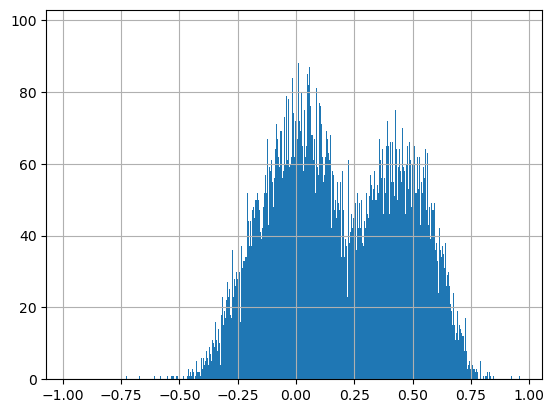

In [6]:
filtered.loc["diff_7_minus_10"].hist(bins=1000) 

In [33]:
np.sum(filtered.loc["total_counts_norm"] < 0.37)#/filtered.shape[1]

np.int64(13529)

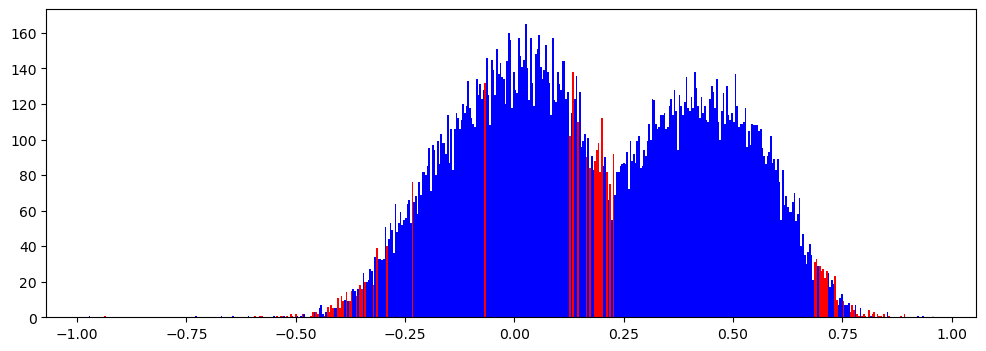

In [42]:
import matplotlib.pyplot as plt
import numpy as np

# данные
x = filtered.loc["diff_7_minus_10"]
qc = filtered.loc["total_counts_norm"]

# гистограмма без отрисовки
counts, bins = np.histogram(x, bins=500)

# средний qc в каждом бине
bin_idx = np.digitize(x, bins) - 1
bin_qc = np.full(len(counts), np.nan)

for i in range(len(counts)):
    mask = bin_idx == i
    if mask.any():
        bin_qc[i] = qc[mask].mean()

threshold = 0.37  # <-- задайте свой порог

bright = 'red'  # яркий (желтый)
dark = 'blue'    # темный (фиолетовый)

fig, ax = plt.subplots(figsize=(12, 4))

for left, right, h, q in zip(bins[:-1], bins[1:], counts, bin_qc):
    if np.isnan(q):
        color = "lightgray"
    elif q < threshold:
        color = bright
    else:
        color = dark

    ax.bar(left, h, width=right-left, align="edge", color=color)

plt.show()

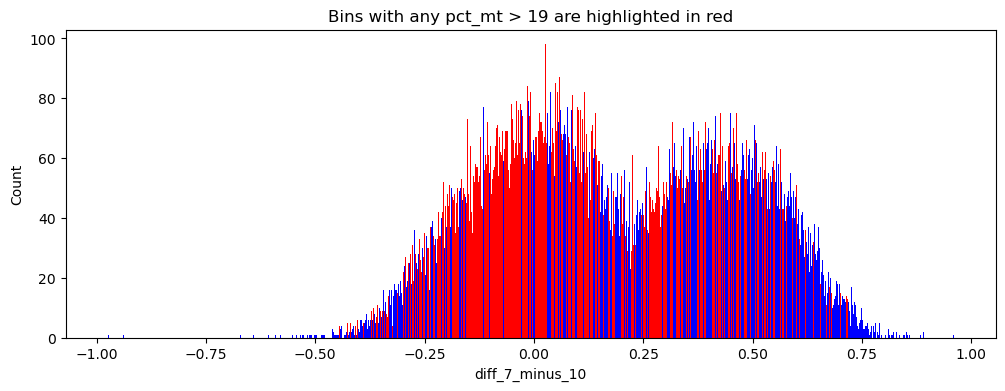

In [27]:
import matplotlib.pyplot as plt
import numpy as np

# Данные
x = filtered.loc["diff_7_minus_10"]
pct_mt = filtered.loc["pct_mt"]

# Гистограмма
counts, bins = np.histogram(x, bins=1000)

# Индекс бина для каждой клетки
bin_idx = np.digitize(x, bins) - 1

threshold = 19

# Для каждого бина определяем, есть ли клетки с pct_mt > threshold
bin_has_high_mt = np.zeros(len(counts), dtype=bool)

for i in range(len(counts)):
    mask = bin_idx == i
    if mask.any():
        bin_has_high_mt[i] = (pct_mt[mask] > threshold).any()

# Рисуем
fig, ax = plt.subplots(figsize=(12, 4))

for left, right, h, high_mt in zip(
    bins[:-1], bins[1:], counts, bin_has_high_mt
):
    color = "red" if high_mt else "blue"

    ax.bar(
        left,
        h,
        width=right - left,
        align="edge",
        color=color,
        edgecolor="none",
    )

ax.set_xlabel("diff_7_minus_10")
ax.set_ylabel("Count")
ax.set_title(f"Bins with any pct_mt > {threshold} are highlighted in red")

plt.show()

<Axes: >

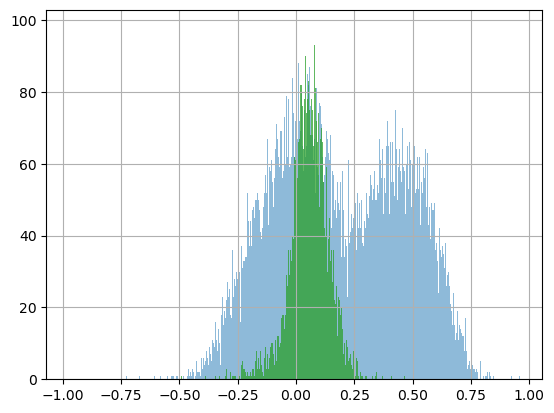

In [34]:
filtered.loc["diff_7_minus_10"].hist(
    bins=1000,
    density=False,
    alpha=0.5,
    label="dataset 1",
    color="tab:blue"
)

chr_means_norm.loc["diff_7_minus_10"].hist(
    bins=300,
    density=False,
    alpha=0.75,
    label="dataset 2",
    color="tab:green"
)

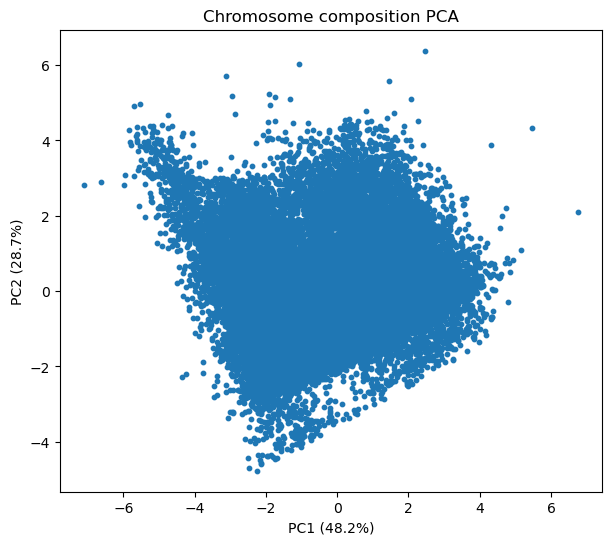

In [8]:
plot_pca(merged)

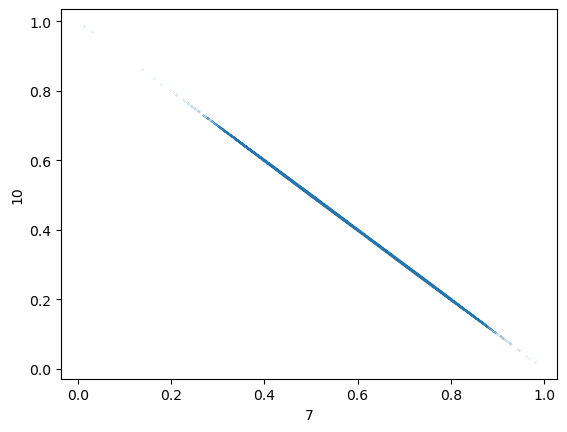

In [9]:
filtered.T.plot.scatter(x="7", y="10", s=0.01, alpha=1)
plt.show()

In [29]:
import importlib
import plots
importlib.reload(plots)
from plots import *

plot_3d_kde(filtered, 'diff_7_minus_10', '1') #4

In [30]:
plot_3d_hist(filtered, '1', 'diff_7_minus_10')

# save

In [17]:
filtered = filtered.loc[:,~filtered.columns.duplicated()]

In [ ]:
filtered.to_parquet(PROJ_ROOT / 'output/cancer_2.parquet')

In [2]:
filtered = pd.read_parquet(PROJ_ROOT / 'output/cancer_1.parquet')

# single cell workflow

In [56]:
df = pd.read_csv(path_smartseq / smartseq_files[2], sep="\t", index_col=0)
df

,GACTACTGAGCT,ACATCTCGGTGA,AGACTCCTATAC,CCACGGACACTA,GAACTCGACCTT,ATGTTATTCACC,GTCTTGATACTA,AGTGGGTGGAAT,CATATCTAATTT,CAATCATCCCTT,...,CCTTACTAATCT,AATGCCATCTTC,ATGGTATGTGGG,CTACGACTGACG,AAGGAGCCAATG,CATACGAGAAAC,CGGTTTTCAGCT,CTTAGGCTTTAA,ATTGCTCTCCGG,TCATATCTGACT
NDUFA6,8,9,8,6,4,2,5,5,1,1,...,0,0,0,0,0,0,0,0,0,0
GALNT11,0,0,3,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
BTG2,4,22,4,8,3,4,4,2,1,1,...,0,0,0,0,1,1,1,0,0,0
TRA2A,5,6,6,13,5,14,6,6,3,4,...,0,0,0,0,1,1,0,0,0,0
SURF2,0,2,1,0,0,0,0,2,2,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
AC019257.2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
AC103996.3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
BUB3P1,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
AC022306.3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [57]:
adata = sc.AnnData(df.T)
adata.obs["Sample"] = smartseq_files[0].split("_")[0]

In [58]:
annotate_qc(adata) # ADD QC METRICS

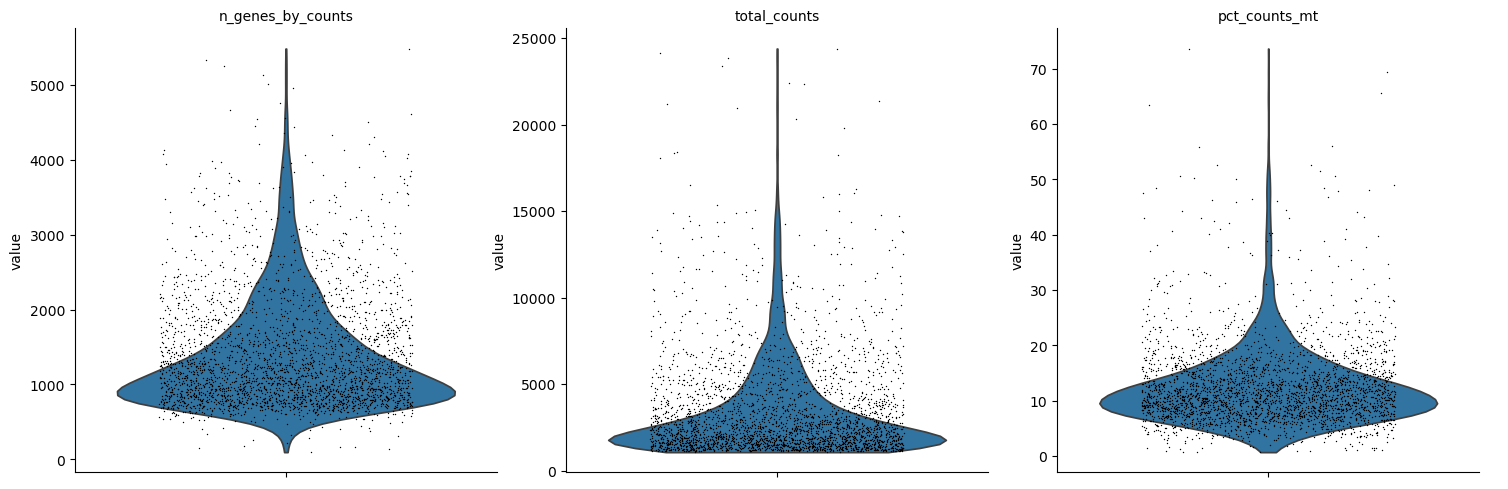

In [59]:
sc.pl.violin(
    adata,
    keys=["n_genes_by_counts", "total_counts", "pct_counts_mt"],
    jitter=0.3,
    multi_panel=True,
) 

In [60]:
adata = apply_qc_filters(adata)

Cells: 2926 -> 2370 | Genes: 31166 -> 18853
0.95th percentile n_genes = 2932
0.95th percentile total_counts = 6772


In [61]:
adata = main_pipeline(adata)

/Users/neuropromotion/Desktop/GCF/new_approach/sc_scripts.py:69: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata, resolution=resolution, key_added='clusters')


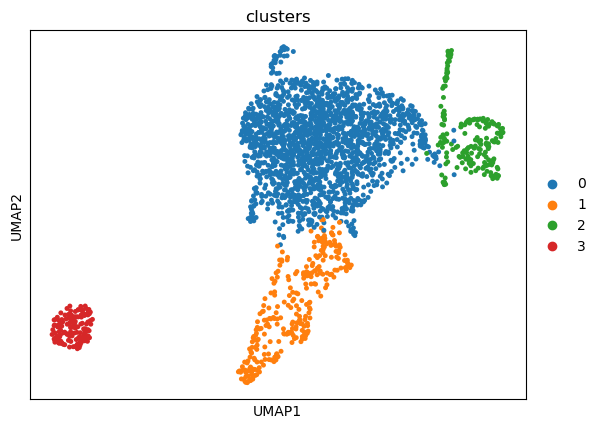

In [62]:
sc.pl.umap(adata, color=['clusters'])

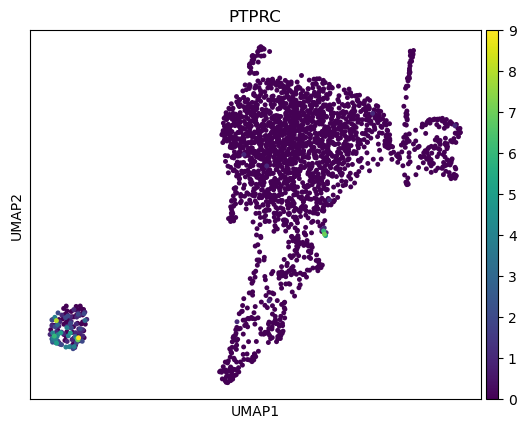

In [64]:
sc.pl.umap(adata, color=['PTPRC'])

# Distribution of gene lengths across chromosomes

In [60]:
df_l = pd.read_parquet(PROJ_ROOT / 'df_gene_length.parquet')
df_chr = pd.read_csv(PROJ_ROOT / 'gene_chromosome_mapping.tsv', sep='\t')

In [62]:
df_chr.rename(columns={'gene': 'gene_id'}, inplace=True)
df_chr

,gene_id,chromosome,arm
0,ENSG00000284616,1,p
1,ENSG00000260972,1,p
2,ENSG00000229280,1,p
3,EEF1DP6,1,p
4,ENSG00000232596,1,p
...,...,...,...
120772,MT-CYB,MT,NaN
120773,ENSG00000210195,MT,NaN
120774,MT-TT,MT,NaN
120775,ENSG00000210196,MT,NaN


In [67]:
shared_genes = list(set(df_l['gene_id']) & set(df_chr['gene_id']))
df_l = df_l[df_l['gene_id'].isin(shared_genes)]
df_chr = df_chr[df_chr['gene_id'].isin(shared_genes)]

In [72]:
merged_chr = pd.merge(df_chr, df_l, on='gene_id', how='left')
merged_chr = merged_chr[['gene_id', 'chromosome', 'gene_length_kb']]
merged_chr

,gene_id,chromosome,gene_length_kb
0,ENSG00000284616,1,5.467
1,ENSG00000260972,1,1.697
2,ENSG00000229280,1,0.372
3,ENSG00000232596,1,22.536
4,ENSG00000231510,1,4.441
...,...,...,...
78655,ENSG00000198695,MT,0.525
78656,ENSG00000210194,MT,0.069
78657,ENSG00000198727,MT,1.141
78658,ENSG00000210195,MT,0.066


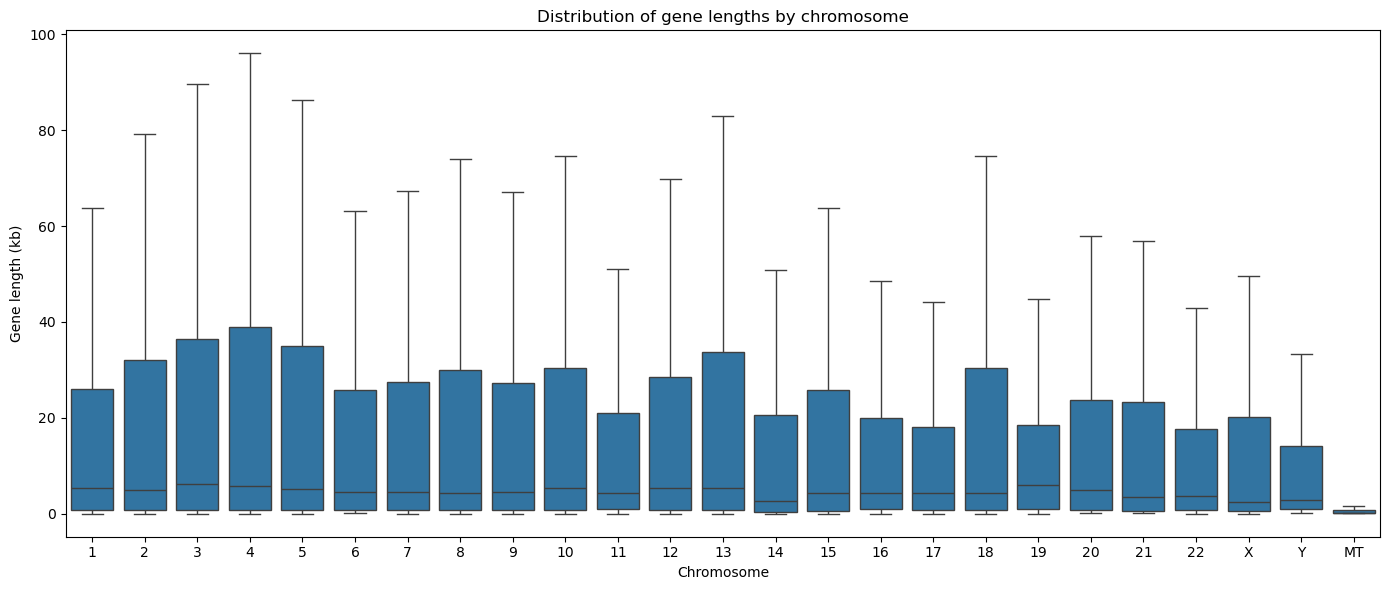

In [73]:
import matplotlib.pyplot as plt
import seaborn as sns

# При необходимости упорядочить хромосомы
chrom_order = [str(i) for i in range(1, 23)] + ["X", "Y", "MT"]
chrom_order = [c for c in chrom_order if c in merged_chr["chromosome"].astype(str).unique()]

plt.figure(figsize=(14, 6))
sns.boxplot(
    data=merged_chr,
    x="chromosome",
    y="gene_length_kb",
    order=chrom_order,
    showfliers=False  # длинные гены не будут растягивать график
)

plt.xlabel("Chromosome")
plt.ylabel("Gene length (kb)")
plt.title("Distribution of gene lengths by chromosome")
plt.tight_layout()
plt.show()

## ML

In [ ]:
filtered.loc['class'] = np.where(filtered.loc['diff_7_minus_10'] > 0.25, 1, 0)
filtered

,AAACCCAAGGCGATAC-1,AAACCCACAAGTCCCG-1,AAACCCACAGATGCGA-1,AAACCCACAGGTGAGT-1,AAACCCAGTCTTGCGG-1,AAACCCATCGATAACC-1,AAACGAAAGACTCAAA-1,AAACGAAAGTAATCCC-1,AAACGAAAGTATGCAA-1,AAACGAACACCACATA-1,...,TTGGGGCCAGAA,TTTCGTTTAGCC,CCGTTTCTCTAC,CTTGAAACAGGG,AAGAGAAATTTA,ACACGGCGTTCT,ATACCGATATGC,ATAGATTACGTA,AAGCAACAACTG,TTTCCGGAGAAT
chromosome,,,,,,,,,,,,,,,,,,,,,
7,0.522492,0.739584,0.337970,0.567269,0.837686,0.383901,0.496431,0.488766,0.749928,0.739981,...,0.610667,0.565388,0.59489,0.562482,0.740067,0.549729,0.742390,0.473396,0.451816,0.842505
10,0.477508,0.260416,0.662030,0.432731,0.162314,0.616099,0.503569,0.511234,0.250072,0.260019,...,0.389333,0.434612,0.40511,0.437518,0.259933,0.450271,0.257610,0.526604,0.548184,0.157495
diff_7_minus_10,0.044985,0.479168,-0.324060,0.134538,0.675373,-0.232197,-0.007137,-0.022469,0.499856,0.479963,...,0.221335,0.130776,0.18978,0.124963,0.480134,0.099458,0.484780,-0.053208,-0.096368,0.685010
1,0.074824,0.830546,0.295335,0.335827,0.205986,0.184859,0.120158,0.505282,1.648768,1.005282,...,0.072968,0.075871,0.08665,0.074627,0.063847,0.065920,0.066335,0.059287,0.063018,0.088723
class,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,...,0.000000,0.000000,0.00000,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,1.000000


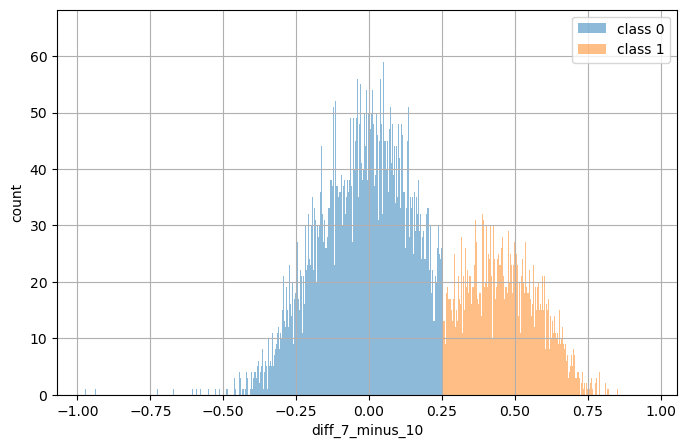

In [40]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 5))

filtered.loc['diff_7_minus_10'][filtered.loc['class'] == 0].hist(
    bins=1000,
    alpha=0.5,
    label='class 0',
    ax=ax
)

filtered.loc['diff_7_minus_10'][filtered.loc['class'] == 1].hist(
    bins=1000,
    alpha=0.5,
    label='class 1',
    ax=ax
)

ax.set_xlabel('diff_7_minus_10')
ax.set_ylabel('count')
ax.legend()

plt.show()

# загружаем все хромосомы и обучаем модели предсказывать классы на них, но без 7/10

In [41]:
chr_means_smartseq_list = []
for file in smartseq_files:
    df = sc_loader.run_pipeline_v3(
                                    str(path_smartseq / file),
                                    _10x=False,
                                    use_cpm=False,              # False → сырые counts
                                    log=False,                 # log1p после нормировки на n_genes
                                    mode="all_shares",           # "vs_background" | "all_shares"
                                    drop_chroms=("6"),
                                    verbose=True,
                                    )
    chr_means_smartseq_list.append(df)

 
chr_means = sc_loader.run_pipeline_v3(
                                    path_10x,
                                    _10x=True,
                                    use_cpm=False,              # False → сырые counts
                                    log=False,                 # log1p после нормировки на n_genes
                                    mode="all_shares",           # "vs_background" | "all_shares"
                                    drop_chroms=("6"),
                                    verbose=True,
                                    )
chr_means_smartseq = pd.concat(chr_means_smartseq_list, axis=1)

 
merged = pd.concat([chr_means, chr_means_smartseq], axis=1) 
merged

Cells: 2643 -> 2367 | Genes: 28928 -> 18180
0.95th percentile n_genes = 2706
0.95th percentile total_counts = 5611
v3 | use_cpm=False log=False mode=all_shares | drop=6 | chroms=['1', '2', '3', '4', '5', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21', '22'] | cells=2358
  7: mean=0.0482 std=0.0142
  10: mean=0.0408 std=0.0121
Cells: 3196 -> 2324 | Genes: 30331 -> 19479
0.95th percentile n_genes = 3550
0.95th percentile total_counts = 10656
v3 | use_cpm=False log=False mode=all_shares | drop=6 | chroms=['1', '2', '3', '4', '5', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21', '22'] | cells=2296
  7: mean=0.0426 std=0.0159
  10: mean=0.0442 std=0.0144
Cells: 2926 -> 2370 | Genes: 31166 -> 18853
0.95th percentile n_genes = 2932
0.95th percentile total_counts = 6772
v3 | use_cpm=False log=False mode=all_shares | drop=6 | chroms=['1', '2', '3', '4', '5', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17'

,AAACCCAAGGCGATAC-1,AAACCCACAAGTCCCG-1,AAACCCACAGATGCGA-1,AAACCCACAGGTGAGT-1,AAACCCAGTCTTGCGG-1,AAACCCATCGATAACC-1,AAACGAAAGACTCAAA-1,AAACGAAAGTAATCCC-1,AAACGAAAGTATGCAA-1,AAACGAACACCACATA-1,...,TTGGGGCCAGAA,TTTCGTTTAGCC,CCGTTTCTCTAC,CTTGAAACAGGG,AAGAGAAATTTA,ACACGGCGTTCT,ATACCGATATGC,ATAGATTACGTA,AAGCAACAACTG,TTTCCGGAGAAT
chromosome,,,,,,,,,,,,,,,,,,,,,
1,0.043280,0.054372,0.047059,0.042926,0.043161,0.036532,0.047642,0.040579,0.064465,0.058194,...,0.047802,0.049603,0.063739,0.054048,0.044355,0.045495,0.046224,0.037702,0.047539,0.060078
2,0.039572,0.043825,0.033621,0.040782,0.046623,0.035885,0.055266,0.032761,0.035974,0.038456,...,0.054452,0.061082,0.061615,0.052265,0.053714,0.043134,0.062858,0.055726,0.045204,0.068499
3,0.052542,0.037800,0.026179,0.042709,0.039060,0.031220,0.032885,0.027277,0.037524,0.042570,...,0.059601,0.047887,0.049909,0.049139,0.050348,0.036184,0.048353,0.048540,0.025592,0.046465
4,0.039238,0.043490,0.044541,0.041860,0.034555,0.049925,0.100631,0.170201,0.037956,0.041706,...,0.045960,0.061156,0.067989,0.054843,0.042549,0.099141,0.051214,0.057361,0.037802,0.051276
5,0.060400,0.039168,0.054413,0.041365,0.043957,0.038855,0.052592,0.033998,0.040460,0.039264,...,0.044719,0.058539,0.054778,0.053291,0.045574,0.045276,0.048802,0.047920,0.050157,0.058830
7,0.023306,0.069961,0.029767,0.046470,0.084620,0.030041,0.030136,0.038169,0.062336,0.068437,...,0.056888,0.051992,0.042360,0.048327,0.061596,0.035958,0.050956,0.044178,0.035857,0.050136
8,0.040278,0.067856,0.041291,0.038814,0.043773,0.031809,0.029420,0.030162,0.092926,0.090533,...,0.040803,0.045999,0.058542,0.050956,0.048877,0.034229,0.051438,0.053544,0.040894,0.052328
9,0.045433,0.037376,0.037174,0.060540,0.037338,0.036837,0.033467,0.040296,0.040886,0.036375,...,0.049348,0.039970,0.043364,0.040324,0.035645,0.024863,0.046404,0.048597,0.026353,0.053225
10,0.021300,0.024634,0.058309,0.035449,0.016396,0.048212,0.030570,0.039924,0.020787,0.024048,...,0.036269,0.039966,0.028847,0.037591,0.021634,0.029453,0.017682,0.049143,0.043505,0.009372


In [84]:
merged_filtered = merged.drop(['7', '10'])
merged_filtered.loc['class'] = filtered.loc['class'].reindex(
    merged_filtered.columns
).astype(int) 
merged_filtered

,AAACCCAAGGCGATAC-1,AAACCCACAAGTCCCG-1,AAACCCACAGATGCGA-1,AAACCCACAGGTGAGT-1,AAACCCAGTCTTGCGG-1,AAACCCATCGATAACC-1,AAACGAAAGACTCAAA-1,AAACGAAAGTAATCCC-1,AAACGAAAGTATGCAA-1,AAACGAACACCACATA-1,...,TTGGGGCCAGAA,TTTCGTTTAGCC,CCGTTTCTCTAC,CTTGAAACAGGG,AAGAGAAATTTA,ACACGGCGTTCT,ATACCGATATGC,ATAGATTACGTA,AAGCAACAACTG,TTTCCGGAGAAT
chromosome,,,,,,,,,,,,,,,,,,,,,
1,0.043280,0.054372,0.047059,0.042926,0.043161,0.036532,0.047642,0.040579,0.064465,0.058194,...,0.047802,0.049603,0.063739,0.054048,0.044355,0.045495,0.046224,0.037702,0.047539,0.060078
2,0.039572,0.043825,0.033621,0.040782,0.046623,0.035885,0.055266,0.032761,0.035974,0.038456,...,0.054452,0.061082,0.061615,0.052265,0.053714,0.043134,0.062858,0.055726,0.045204,0.068499
3,0.052542,0.037800,0.026179,0.042709,0.039060,0.031220,0.032885,0.027277,0.037524,0.042570,...,0.059601,0.047887,0.049909,0.049139,0.050348,0.036184,0.048353,0.048540,0.025592,0.046465
4,0.039238,0.043490,0.044541,0.041860,0.034555,0.049925,0.100631,0.170201,0.037956,0.041706,...,0.045960,0.061156,0.067989,0.054843,0.042549,0.099141,0.051214,0.057361,0.037802,0.051276
5,0.060400,0.039168,0.054413,0.041365,0.043957,0.038855,0.052592,0.033998,0.040460,0.039264,...,0.044719,0.058539,0.054778,0.053291,0.045574,0.045276,0.048802,0.047920,0.050157,0.058830
8,0.040278,0.067856,0.041291,0.038814,0.043773,0.031809,0.029420,0.030162,0.092926,0.090533,...,0.040803,0.045999,0.058542,0.050956,0.048877,0.034229,0.051438,0.053544,0.040894,0.052328
9,0.045433,0.037376,0.037174,0.060540,0.037338,0.036837,0.033467,0.040296,0.040886,0.036375,...,0.049348,0.039970,0.043364,0.040324,0.035645,0.024863,0.046404,0.048597,0.026353,0.053225
11,0.085158,0.101700,0.117039,0.083296,0.081083,0.161372,0.121213,0.088709,0.098612,0.082664,...,0.053963,0.073780,0.070287,0.073379,0.163089,0.108013,0.052807,0.058669,0.086995,0.079762
12,0.057702,0.056970,0.044068,0.053804,0.058969,0.069400,0.036016,0.048915,0.055652,0.051503,...,0.051279,0.052742,0.069329,0.063632,0.048274,0.043548,0.060109,0.050793,0.039164,0.063820


In [85]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score

# целевая переменная
y = merged_filtered.loc['class'].astype(int)

# признаки (убираем class)
X = merged_filtered.drop('class').T

print(X.shape, y.shape)

(27219, 19) (27219,)


In [86]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

model = LogisticRegression(
    max_iter=1000,
    n_jobs=-1
)

model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [87]:
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.84147685525349
              precision    recall  f1-score   support

           0       0.86      0.87      0.86      3136
           1       0.82      0.80      0.81      2308

    accuracy                           0.84      5444
   macro avg       0.84      0.84      0.84      5444
weighted avg       0.84      0.84      0.84      5444



In [116]:
coef = model.coef_[0]

feature_importance = (
    pd.Series(coef, index=X.columns)
    .sort_values()
)

print("Топ признаков для class 0:")
print(feature_importance.head(5))

print("\nТоп признаков для class 1:")
print(feature_importance.tail(5))

Топ признаков для class 0:
chromosome
14   -21.631340
4    -17.977745
15   -16.605402
19   -16.492567
13   -14.538902
dtype: float64

Топ признаков для class 1:
chromosome
11     6.969124
3     11.362389
8     13.365152
20    15.075258
12    19.208075
dtype: float64


In [89]:
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt

# нужны вероятности класса 1, а не predict()
y_score = model.predict_proba(X_test)[:, 1]

auc = roc_auc_score(y_test, y_score)

print("ROC-AUC:", auc)

ROC-AUC: 0.9210854050242281


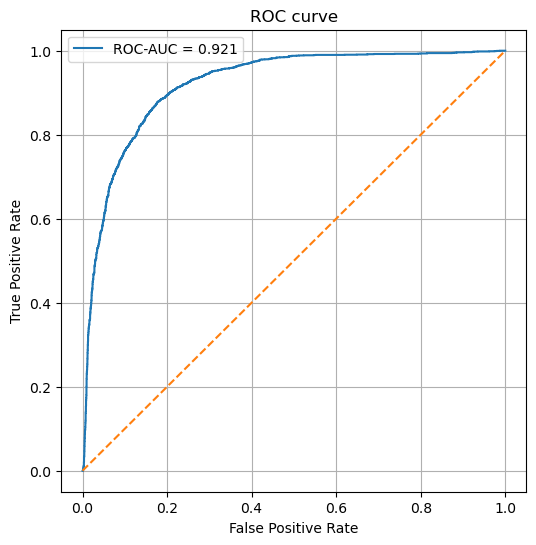

In [90]:
fpr, tpr, thresholds = roc_curve(y_test, y_score)

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f"ROC-AUC = {auc:.3f}")

plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC curve")
plt.legend()
plt.grid()

plt.show()

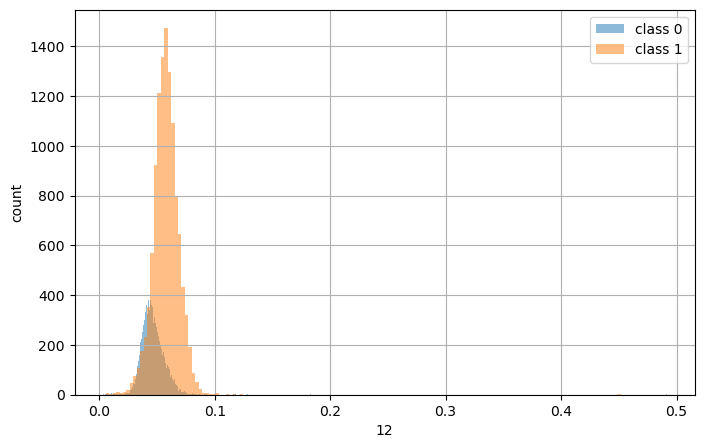

In [118]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 5))
feature = '12'
merged_filtered.loc[feature][merged_filtered.loc['class'] == 0].hist(
    bins=1000,
    alpha=0.5,
    label='class 0',
    ax=ax
)

merged_filtered.loc[feature][merged_filtered.loc['class'] == 1].hist(
    bins=150,
    alpha=0.5,
    label='class 1',
    ax=ax
)

ax.set_xlabel(feature)
ax.set_ylabel('count')
ax.legend()

plt.show()

In [120]:
merged_filtered.loc['12_14'] = np.log1p(merged_filtered.loc['12'] / merged_filtered.loc['14'])
merged_filtered

,AAACCCAAGGCGATAC-1,AAACCCACAAGTCCCG-1,AAACCCACAGATGCGA-1,AAACCCACAGGTGAGT-1,AAACCCAGTCTTGCGG-1,AAACCCATCGATAACC-1,AAACGAAAGACTCAAA-1,AAACGAAAGTAATCCC-1,AAACGAAAGTATGCAA-1,AAACGAACACCACATA-1,...,TTGGGGCCAGAA,TTTCGTTTAGCC,CCGTTTCTCTAC,CTTGAAACAGGG,AAGAGAAATTTA,ACACGGCGTTCT,ATACCGATATGC,ATAGATTACGTA,AAGCAACAACTG,TTTCCGGAGAAT
chromosome,,,,,,,,,,,,,,,,,,,,,
1,0.043280,0.054372,0.047059,0.042926,0.043161,0.036532,0.047642,0.040579,0.064465,0.058194,...,0.047802,0.049603,0.063739,0.054048,0.044355,0.045495,0.046224,0.037702,0.047539,0.060078
2,0.039572,0.043825,0.033621,0.040782,0.046623,0.035885,0.055266,0.032761,0.035974,0.038456,...,0.054452,0.061082,0.061615,0.052265,0.053714,0.043134,0.062858,0.055726,0.045204,0.068499
3,0.052542,0.037800,0.026179,0.042709,0.039060,0.031220,0.032885,0.027277,0.037524,0.042570,...,0.059601,0.047887,0.049909,0.049139,0.050348,0.036184,0.048353,0.048540,0.025592,0.046465
4,0.039238,0.043490,0.044541,0.041860,0.034555,0.049925,0.100631,0.170201,0.037956,0.041706,...,0.045960,0.061156,0.067989,0.054843,0.042549,0.099141,0.051214,0.057361,0.037802,0.051276
5,0.060400,0.039168,0.054413,0.041365,0.043957,0.038855,0.052592,0.033998,0.040460,0.039264,...,0.044719,0.058539,0.054778,0.053291,0.045574,0.045276,0.048802,0.047920,0.050157,0.058830
8,0.040278,0.067856,0.041291,0.038814,0.043773,0.031809,0.029420,0.030162,0.092926,0.090533,...,0.040803,0.045999,0.058542,0.050956,0.048877,0.034229,0.051438,0.053544,0.040894,0.052328
9,0.045433,0.037376,0.037174,0.060540,0.037338,0.036837,0.033467,0.040296,0.040886,0.036375,...,0.049348,0.039970,0.043364,0.040324,0.035645,0.024863,0.046404,0.048597,0.026353,0.053225
11,0.085158,0.101700,0.117039,0.083296,0.081083,0.161372,0.121213,0.088709,0.098612,0.082664,...,0.053963,0.073780,0.070287,0.073379,0.163089,0.108013,0.052807,0.058669,0.086995,0.079762
12,0.057702,0.056970,0.044068,0.053804,0.058969,0.069400,0.036016,0.048915,0.055652,0.051503,...,0.051279,0.052742,0.069329,0.063632,0.048274,0.043548,0.060109,0.050793,0.039164,0.063820


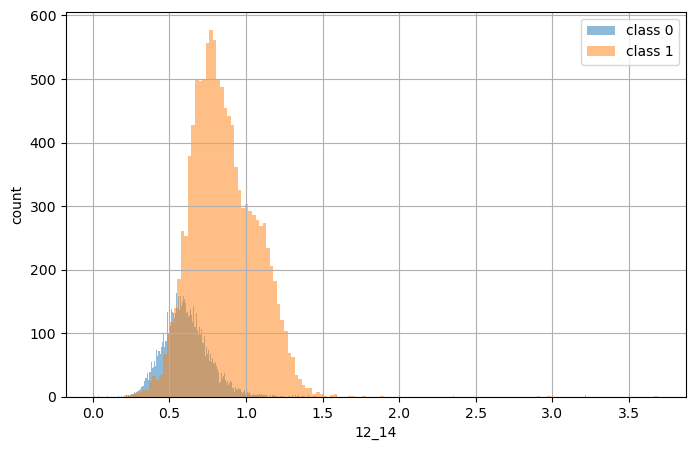

In [122]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 5))
feature = '12_14'
merged_filtered.loc[feature][merged_filtered.loc['class'] == 0].hist(
    bins=1000,
    alpha=0.5,
    label='class 0',
    ax=ax
)

merged_filtered.loc[feature][merged_filtered.loc['class'] == 1].hist(
    bins=150,
    alpha=0.5,
    label='class 1',
    ax=ax
)

ax.set_xlabel(feature)
ax.set_ylabel('count')
ax.legend()

plt.show()

# healthy cells normally distributed?

In [125]:
x = chr_means_norm.loc["diff_7_minus_10"]

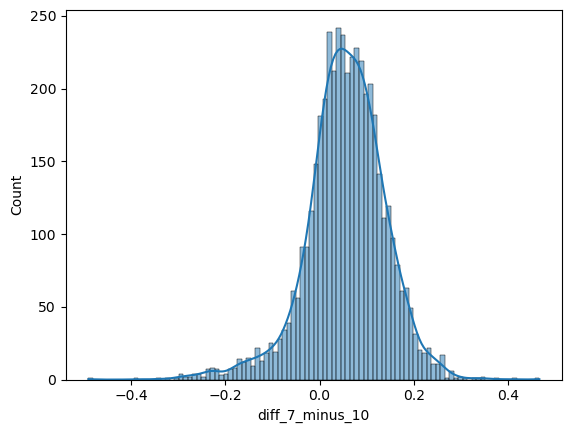

In [126]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(x, bins=100, kde=True)

plt.xlabel("diff_7_minus_10")
plt.show()

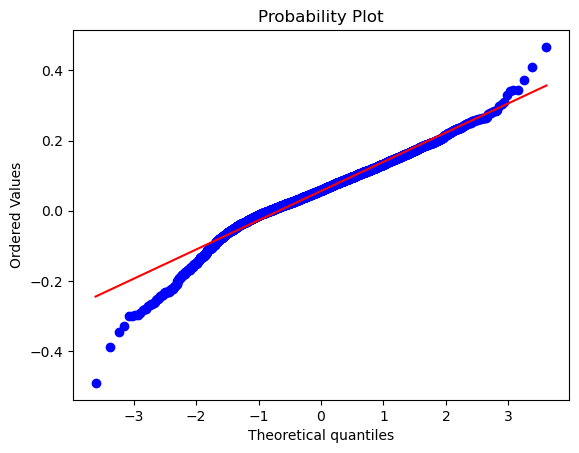

In [127]:
import scipy.stats as stats
import matplotlib.pyplot as plt

stats.probplot(x, dist="norm", plot=plt)

plt.show()

In [128]:
from scipy.stats import shapiro

stat, p = shapiro(x)

print("statistic:", stat)
print("p-value:", p)

statistic: 0.9722498276864268
p-value: 9.974328834026506e-29


In [130]:
from scipy.stats import anderson

result = anderson(x, dist='norm')

result.statistic

np.float64(21.277717287293854)

In [131]:
result.critical_values

array([0.575, 0.655, 0.786, 0.917, 1.091])

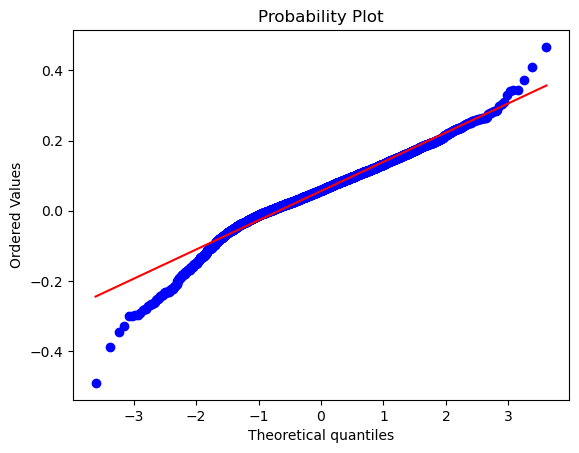

skew: -0.5786881734775757
kurtosis: 2.1980450555822477


In [133]:
x = chr_means_norm.loc["diff_7_minus_10"]

stats.probplot(x, dist="norm", plot=plt)
plt.show()

print("skew:", stats.skew(x))
print("kurtosis:", stats.kurtosis(x))

In [134]:
from scipy.stats import kstest, norm

x = chr_means_norm.loc["diff_7_minus_10"]

# стандартизируем, чтобы сравнивать с N(0,1)
x_std = (x - x.mean()) / x.std()

stat, p = kstest(x_std, 'norm')

print("KS statistic:", stat)
print("p-value:", p)

KS statistic: 0.05144161210149323
p-value: 8.166225705531611e-11
